In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('/content/DSGP1 (1).csv')

In [4]:
df.head()

,Cluster_Label,RH2M,rootSoilMoist,PCACOMP1,temp
0,0,0.786125,0.348853,151.705814,-0.340549
1,0,0.677060,0.501130,87.693701,-0.350461
2,0,0.566542,0.336604,30.599865,-0.249253
3,1,0.499693,0.248090,-5.715133,-0.127191
4,1,0.525004,0.190134,-42.105319,-0.030460


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(columns=["Cluster_Label"])
Y=df["Cluster_Label"]
x_train_split,x_test_split,y_train_split,y_test_split=train_test_split(X,Y,test_size=0.2,random_state=42)

knn=RandomForestClassifier(n_estimators=100)
knn.fit(x_train_split,y_train_split)

y_pred=knn.predict(x_test_split)
traing=accuracy_score(y_test_split,y_pred)
print(traing)

y_test=knn.predict(x_test_split)
validation_traninig=accuracy_score(y_test_split,y_test)
print(validation_traninig)

from sklearn.metrics import classification_report
print(classification_report(y_test_split,y_pred))

0.9831932773109243
0.9831932773109243
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        98
           1       0.98      0.99      0.99       140

    accuracy                           0.98       238
   macro avg       0.98      0.98      0.98       238
weighted avg       0.98      0.98      0.98       238



In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.96928636 0.97397959 0.99127054 0.97814983 0.98260167]
Mean F1-Score: 0.9790576000014916


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(columns=["Cluster_Label"])
y=df["Cluster_Label"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


y_train_pred = model.predict(X_train)
training_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {training_accuracy * 100:.2f}%")


y_val_pred = model.predict(X_val)
validation_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")


Training Accuracy: 100.00%
Validation Accuracy: 98.32%


1, trainng Loss: 1.2719, val Loss: 0.8575
2, trainng Loss: 0.5168, val Loss: 0.4915
3, trainng Loss: 0.4601, val Loss: 0.4543
4, trainng Loss: 0.4498, val Loss: 0.4465
5, trainng Loss: 0.4418, val Loss: 0.4733
6, trainng Loss: 0.4407, val Loss: 0.5068
7, trainng Loss: 0.4388, val Loss: 0.4609
8, trainng Loss: 0.4279, val Loss: 0.4556
9, trainng Loss: 0.4186, val Loss: 0.4508
10, trainng Loss: 0.4087, val Loss: 0.4246


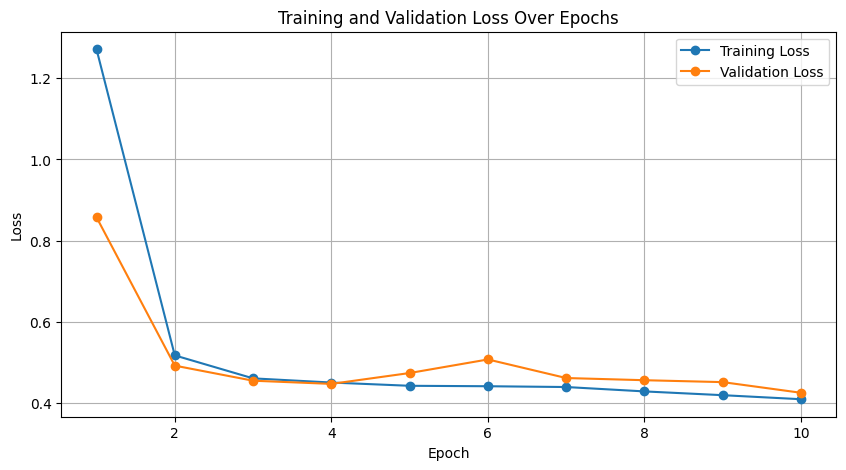

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       149
           1       0.86      0.87      0.86       208

    accuracy                           0.84       357
   macro avg       0.84      0.84      0.84       357
weighted avg       0.84      0.84      0.84       357



In [11]:
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

input = torch.tensor(df.drop(columns=['Cluster_Label']).values, dtype=torch.float32)
target = torch.tensor(df['Cluster_Label'].values, dtype=torch.long)


dataset = TensorDataset(input, target)
train_dataset, val_dataset = random_split(dataset, [int(0.7 * len(df)), len(df) - int(0.7 * len(df))])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

input_size = input.shape[1]


model = nn.Sequential(
    nn.Linear(input_size, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)


loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
training_losses = []
validation_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    training_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    validation_losses.append(val_loss)

    print(f"{epoch + 1}, trainng Loss: {train_loss:.4f}, val Loss: {val_loss:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), training_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), validation_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

y_pred = []
y_val = []
model.eval()
with torch.no_grad():
    for inputs, targets in val_loader:
        outputs = model(inputs)
        y_pred.append(torch.argmax(outputs, dim=1))
        y_val.append(targets)

y_pred = torch.cat(y_pred)
y_val = torch.cat(y_val)

print(classification_report(y_val.numpy(), y_pred.numpy()))
